In [37]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

In [38]:
def resize_image(img_path, size):
    try:
        img = cv.imread(img_path)
        if img is None:
            raise ValueError(f"Image at {img_path} could not be read.")
        resized_img = cv.resize(img, size)
        return resized_img
    except Exception as e:
        print(f"Error resizing image {img_path}: {e}")
        return None

Loading dataset...
Dataset loaded with 210 images across 3 classes.


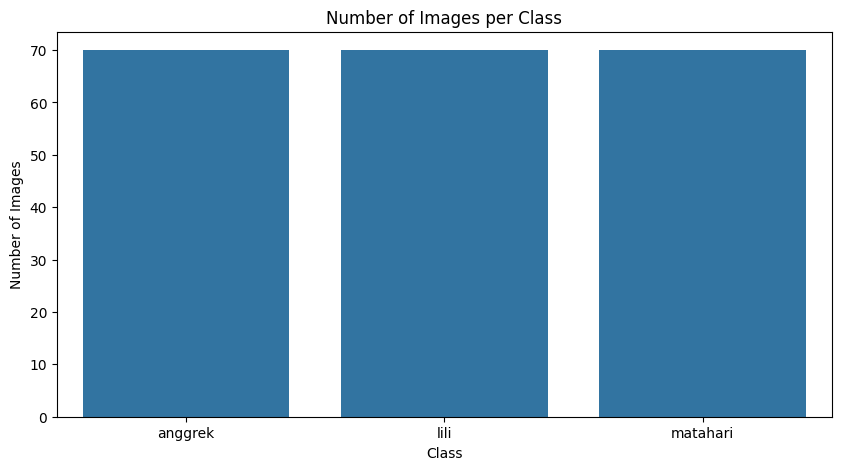

In [39]:
def load_dataset(dir):
    size = (256,256)
    images = []
    labels = []
    class_names = os.listdir(dir)
    class_counter = {class_name: 0 for class_name in class_names}

    for label, class_name in enumerate(class_names):
        class_dir = os.path.join(dir, class_name)
        if os.path.isdir(class_dir):
            for file_name in os.listdir(class_dir):
                if class_counter[class_name] >= 100:
                    break
                img_path = os.path.join(class_dir, file_name)
                img = resize_image(img_path, size)
                if img is not None:
                    images.append(img)
                    labels.append(class_name)
                    class_counter[class_name]+=1
    return np.array(images), np.array(labels), class_names, class_counter


print("Loading dataset...")
images, labels, class_names, class_counter = load_dataset('dataset')
print(f"Dataset loaded with {len(images)} images across {len(class_names)} classes.")
# Diagram Dataset
plt.figure(figsize=(10, 5))
sns.barplot(x=list(class_counter.keys()), y=list(class_counter.values()))
plt.title('Number of Images per Class')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.savefig('dataset_distribution.png')
plt.show()

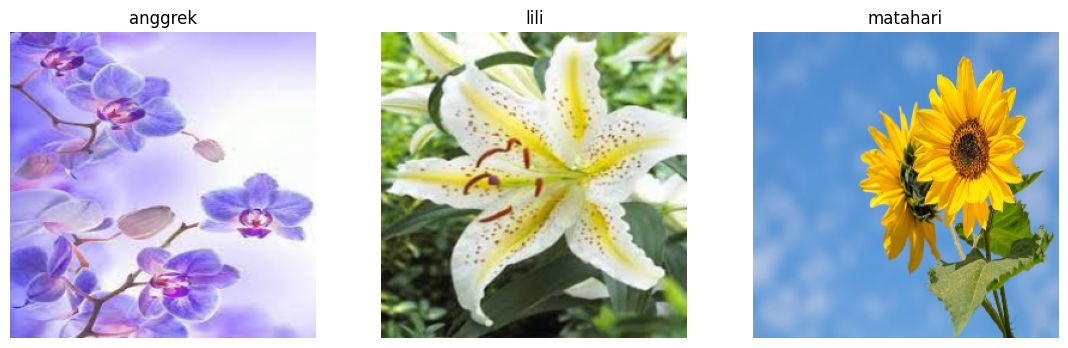

In [40]:
# Menampilkan gambar sample dari setiap kelas
def show_sample_images(images, labels, class_names):
    plt.figure(figsize=(15, 10))
    for i, class_name in enumerate(class_names):
        class_images = images[labels == class_name]
        if len(class_images) > 0:
            plt.subplot(3, 4, i + 1)
            plt.imshow(cv.cvtColor(class_images[10], cv.COLOR_BGR2RGB))
            plt.title(class_name)
            plt.axis('off')
    plt.tight_layout()
    plt.show()
show_sample_images(images, labels, class_names)

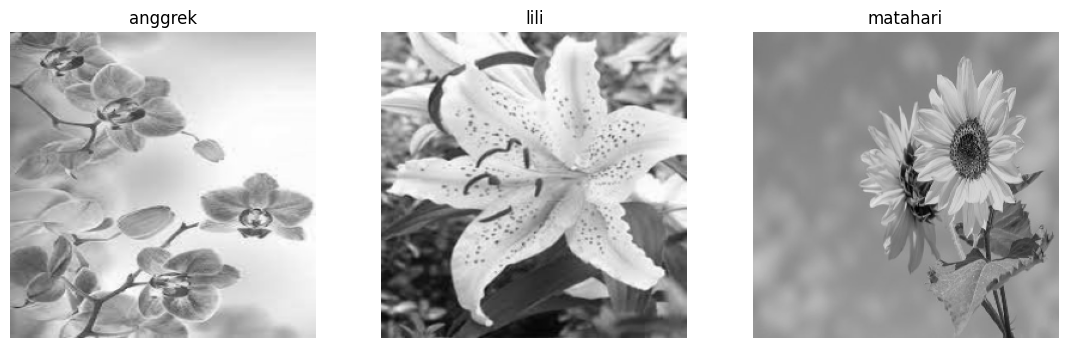

In [41]:
img_grey = []
for img in images:
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    img_grey.append(gray)
img_grey = np.array(img_grey)

show_sample_images(img_grey, labels, class_names)

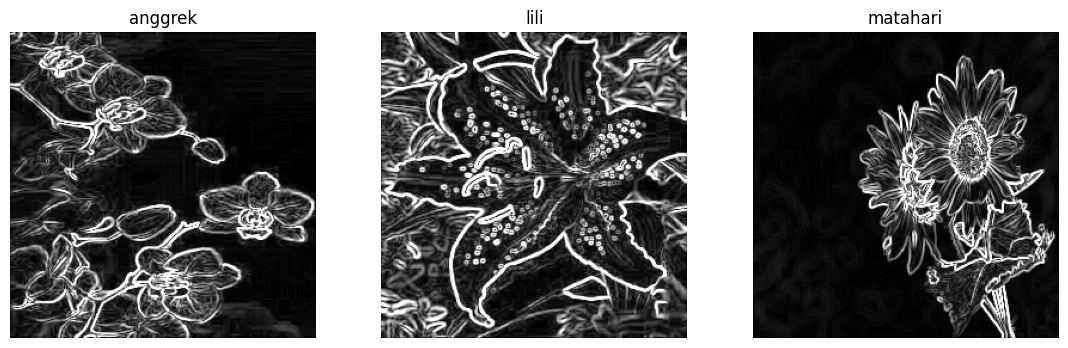

In [42]:
# Kernel Sobel
Sx = np.array([[-1, 0, 1],
               [-2, 0, 2],
               [-1, 0, 1]])

Sy = np.array([[1,  2,  1],
               [0,  0,  0],
               [-1, -2, -1]])


def padding_baris(image):
    height, width = image.shape
    img_pad = np.zeros((height, width + 1))
    img_pad[:, :width] = image
    return img_pad

def padding_kolom(image):
    height, width = image.shape
    img_pad = np.zeros((height + 1, width))
    img_pad[:height, :] = image
    return img_pad

# Fungsi konvolusi edge
def convo_edge(image, kernel, jenis):
    img_height, img_width = image.shape
    k_height, k_width = kernel.shape
    p_height, p_width = k_height // 2, k_width // 2

    if jenis.lower() != "roberts":
        padded_img = np.pad(image, ((p_height, p_height), (p_width, p_width)), mode='reflect')
    else:
        padded_img = padding_kolom(padding_baris(image))

    result = np.zeros((img_height, img_width))

    for i in range(img_height):
        for j in range(img_width):
            region = padded_img[i:i + k_height, j:j + k_width]
            result[i, j] = np.sum(region * kernel)

    return result

# Fungsi deteksi tepi
def deteksi_tepi(image, kernelX, kernelY, jenis):
    hasilX = convo_edge(image, kernelX, jenis)
    hasilY = convo_edge(image, kernelY, jenis)
    magnitude = np.sqrt(hasilX**2 + hasilY**2)
    return np.clip(magnitude, 0, 255).astype(np.uint8)

# Proses ke semua gambar
img_sobel = []
for img in img_grey:
    sobel = deteksi_tepi(img, Sx, Sy, jenis="sobel")
    img_sobel.append(sobel)
img_sobel = np.array(img_sobel)

# Tampilkan sample gambar
show_sample_images(img_sobel, labels, class_names)


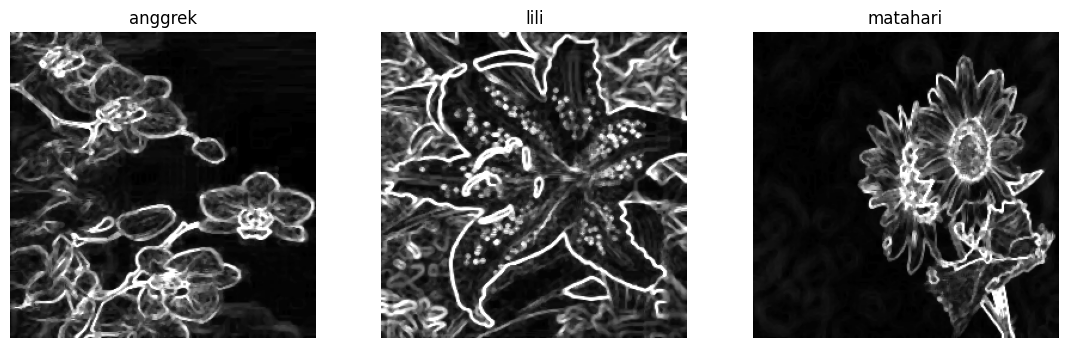

In [43]:
kernel_3x3 = np.full((3, 3), 1/9)

def hitung_median(image):
    return np.median(image)

def convo_statistik(image, kernel):
    img_height, img_width = image.shape
    kernel_height, kernel_width = kernel.shape
    pad_height = kernel_height // 2
    pad_width = kernel_width // 2
    padded_img = np.pad(image, ((pad_height, pad_height), (pad_width, pad_width)), mode='edge')
    result = np.zeros_like(image)

    for i in range(img_height):
        for j in range(img_width):
            tmp = padded_img[i:i+kernel_height, j:j+kernel_width]
            result[i, j] = hitung_median(tmp)
    return result

# Menerapkan konvolusi median
img_median = []
for img in img_sobel:
    median_img = convo_statistik(img, kernel_3x3)
    img_median.append(median_img)
img_median = np.array(img_median)
show_sample_images(img_median, labels, class_names)

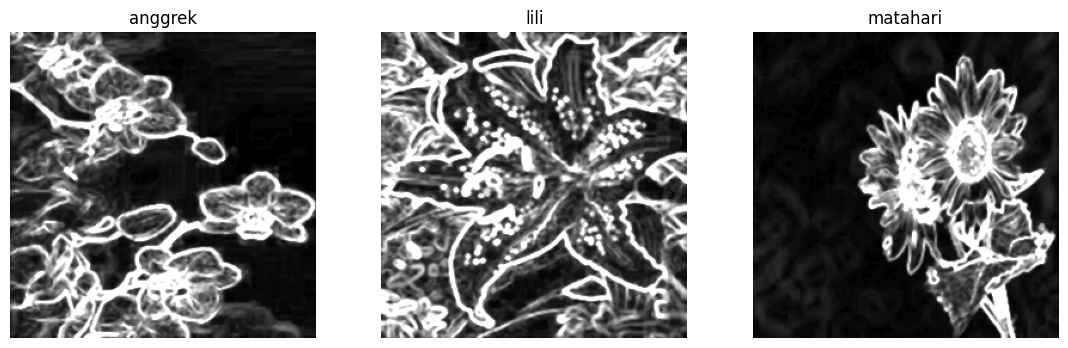

In [44]:
#Fungsi Sharpening
def sharpen_image(image):
    kernel = np.array([[1/9,1/9,1/9],
                             [1/9,8/9,1/9],
                             [1/9,1/9,1/9]])
    sharpened = cv.filter2D(image, -1, kernel)
    return sharpened
# Melakukan sharpening pada gambar
img_sharpened = []
for img in img_median:
    sharpened = sharpen_image(img)
    img_sharpened.append(sharpened)
img_sharpened = np.array(img_sharpened)


show_sample_images(img_sharpened, labels, class_names)

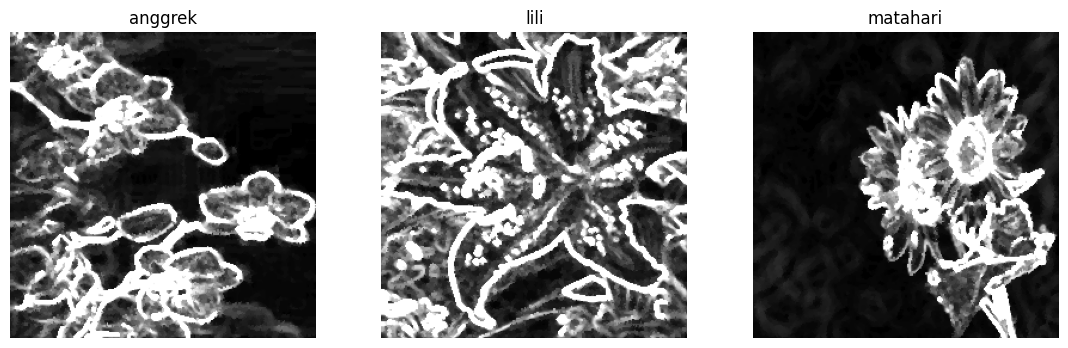

In [45]:
kernel_3x3 = np.full((3, 3), 1/9)

def hitung_modus(image):
    image = image.flatten()
    count = {}
    for num in image:
        if num in count:
            count[num] += 1
        else:
            count[num] = 1
    max_count = 0
    modus = None
    for num in count:
        if count[num] > max_count:
            max_count = count[num]
            modus = num
    return modus


def convo_statistik(image, kernel):
    img_height, img_width = image.shape
    kernel_height, kernel_width = kernel.shape
    pad_height = kernel_height // 2
    pad_width = kernel_width // 2
    padded_img = np.pad(image, ((pad_height, pad_height), (pad_width, pad_width)), mode='edge')
    result = np.zeros_like(image)

    for i in range(img_height):
        for j in range(img_width):
            tmp = padded_img[i:i+kernel_height, j:j+kernel_width]
            result[i, j] = hitung_modus(tmp) 
    return result

# Menerapkan konvolusi modus
img_prepros = []
for img in img_sharpened:
    mod_img = convo_statistik(img, kernel_3x3)
    img_prepros.append(mod_img)
img_prepros = np.array(img_prepros)
show_sample_images(img_prepros, labels, class_names)

In [46]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    # mengembalikan matrix glcm dari image
    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

In [47]:
def correlation(matriks):
	return graycoprops(matriks, 'correlation')[0, 0]

In [48]:
def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

In [49]:
def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

In [50]:
def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

In [51]:
def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

In [52]:
def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

In [53]:
def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [54]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(img_prepros)):
    D0 = glcm(img_prepros[i], 0)
    D45 = glcm(img_prepros[i], 45)
    D90 = glcm(img_prepros[i], 90)
    D135 = glcm(img_prepros[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

In [55]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []


In [56]:
for i in range(len(img_prepros)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

In [57]:
for i in range(len(img_prepros)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)

In [58]:
for i in range(len(img_prepros)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

In [59]:
for i in range(len(img_prepros)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

In [60]:
for i in range(len(img_prepros)):
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

In [61]:
for i in range(len(img_prepros)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

In [62]:
for i in range(len(img_prepros)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)

In [63]:
dataTable = {'Filename': [f'Image_{i+1}' for i in range(len(img_prepros))],
        'Class': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_pros1.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_pros1.csv')
hasilEkstrak = hasilEkstrak.drop(columns=['Filename'])
x = hasilEkstrak.drop(columns=['Class'])
y = hasilEkstrak['Class']


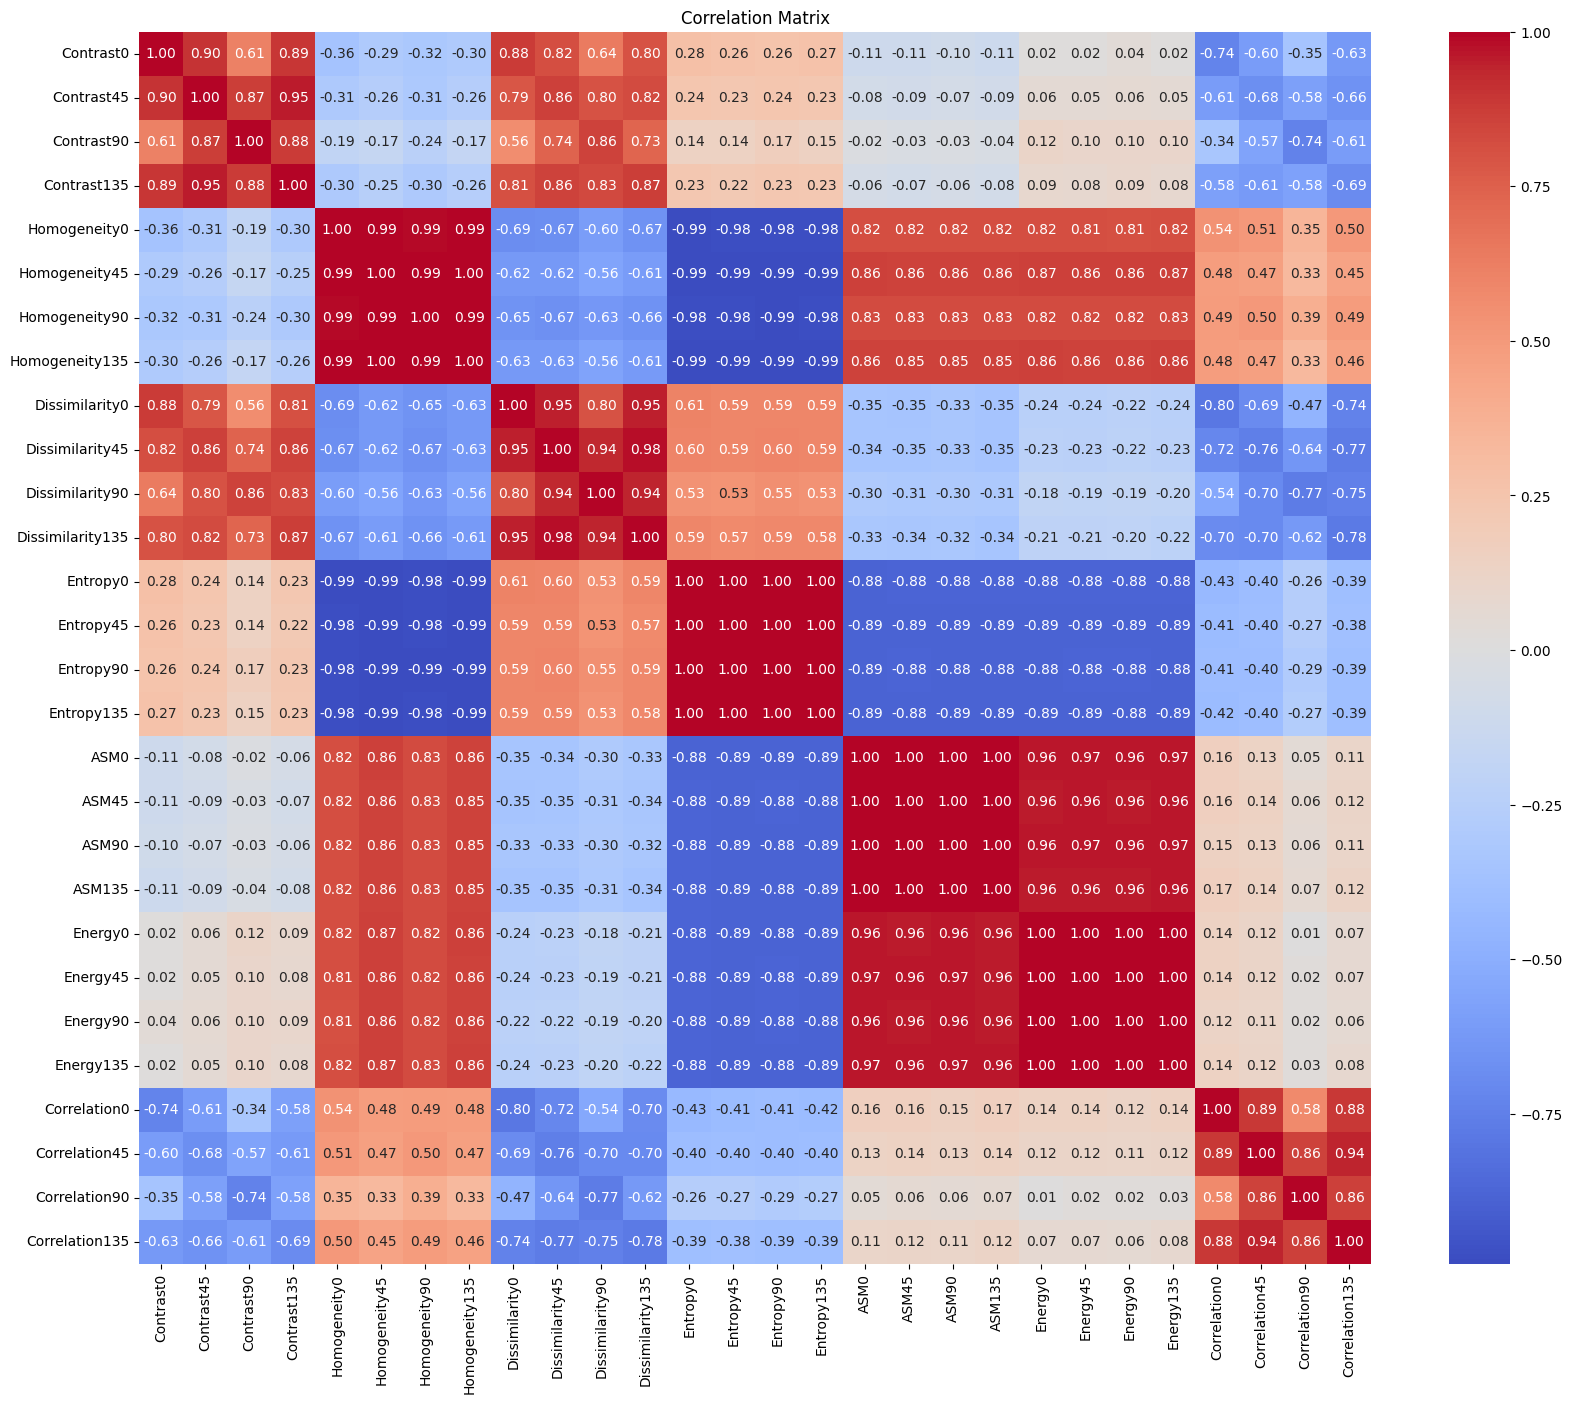

In [64]:
# Menghitung Korelasi
correlation_matrix = x.corr()
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.savefig('correlation_matrix1.png')
plt.show()

In [65]:
# ubah bagian test_size sesuai kebutuhan
# 0.3 = 30% data untuk testing (train/test 70/30)
# 0.2 = 20% data untuk testing (train/test 80/20)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)
print(f"Training set size: {len(x_train)}, Test set size: {len(x_test)}")
print(f"Training set size: {len(y_train)}, Test set size: {len(y_test)}")


Training set size: 147, Test set size: 63
Training set size: 147, Test set size: 63


In [66]:
# normalisasi mean std
def normalize_data(data):
    mean = np.mean(data, axis=0)
    std = np.std(data, axis=0)
    normalized_data = (data - mean) / std
    return normalized_data
x_train = normalize_data(x_train)
x_test = normalize_data(x_test)

In [67]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

In [68]:
# Train Random Forest Classifier
rf.fit(x_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(x_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(x_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

     anggrek       0.90      0.92      0.91        50
        lili       0.92      0.96      0.94        49
    matahari       0.96      0.90      0.92        48

    accuracy                           0.93       147
   macro avg       0.93      0.93      0.93       147
weighted avg       0.93      0.93      0.93       147

[[46  2  2]
 [ 2 47  0]
 [ 3  2 43]]
Accuracy: 0.9251700680272109

------Testing Set------
              precision    recall  f1-score   support

     anggrek       0.47      0.70      0.56        20
        lili       0.67      0.67      0.67        21
    matahari       0.58      0.32      0.41        22

    accuracy                           0.56        63
   macro avg       0.57      0.56      0.55        63
weighted avg       0.57      0.56      0.54        63

[[14  2  4]
 [ 6 14  1]
 [10  5  7]]
Accuracy: 0.5555555555555556


In [69]:
# Train SVM Classifier
svm.fit(x_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(x_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(x_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

     anggrek       0.65      0.72      0.69        50
        lili       0.80      0.65      0.72        49
    matahari       0.65      0.71      0.68        48

    accuracy                           0.69       147
   macro avg       0.70      0.69      0.69       147
weighted avg       0.70      0.69      0.69       147

[[36  3 11]
 [10 32  7]
 [ 9  5 34]]
Accuracy: 0.6938775510204082

------Testing Set------
              precision    recall  f1-score   support

     anggrek       0.44      0.60      0.51        20
        lili       0.76      0.62      0.68        21
    matahari       0.47      0.41      0.44        22

    accuracy                           0.54        63
   macro avg       0.56      0.54      0.54        63
weighted avg       0.56      0.54      0.54        63

[[12  2  6]
 [ 4 13  4]
 [11  2  9]]
Accuracy: 0.5396825396825397


In [70]:
# Train KNN Classifier
knn.fit(x_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(x_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(x_test)
generateClassificationReport( y_test, y_pred)



------Training Set------
              precision    recall  f1-score   support

     anggrek       0.64      0.68      0.66        50
        lili       0.74      0.76      0.75        49
    matahari       0.64      0.58      0.61        48

    accuracy                           0.67       147
   macro avg       0.67      0.67      0.67       147
weighted avg       0.67      0.67      0.67       147

[[34  5 11]
 [ 7 37  5]
 [12  8 28]]
Accuracy: 0.673469387755102

------Testing Set------
              precision    recall  f1-score   support

     anggrek       0.50      0.60      0.55        20
        lili       0.63      0.57      0.60        21
    matahari       0.50      0.45      0.48        22

    accuracy                           0.54        63
   macro avg       0.54      0.54      0.54        63
weighted avg       0.54      0.54      0.54        63

[[12  3  5]
 [ 4 12  5]
 [ 8  4 10]]
Accuracy: 0.5396825396825397


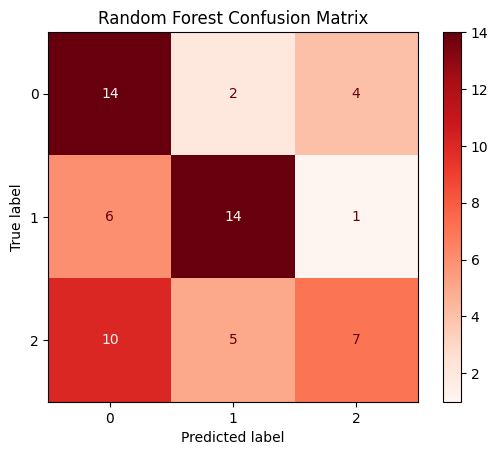

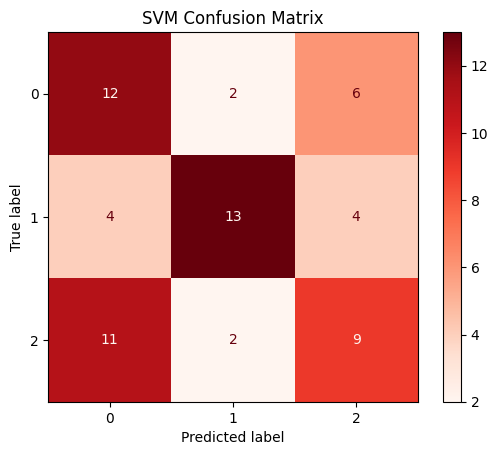

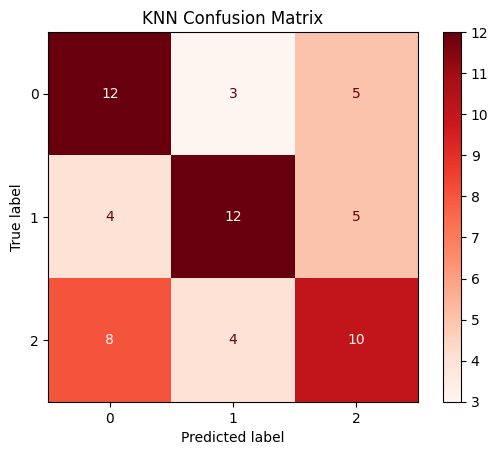

In [71]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Reds)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(x_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(x_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(x_test), "KNN Confusion Matrix")

In [72]:
#Tabel Perbandingan
def display_model_comparison(y_true, rf_pred, svm_pred, knn_pred, model_names=['Random Forest', 'SVM', 'KNN']):
    
    metrics = {
        'Accuracy': accuracy_score,
        'Precision': precision_score,
        'Recall': recall_score,
        'F1-Score': f1_score
    }

    comparison_data = {}

    for name, pred in zip(model_names, [rf_pred, svm_pred, knn_pred]):
        comparison_data[name] = {}
        for metric_name, metric_func in metrics.items():
            if metric_name in ['Precision', 'Recall', 'F1-Score']:
                scores = metric_func(y_true, pred, average='weighted')
                comparison_data[name][metric_name] = scores
            else:
                comparison_data[name][metric_name] = metric_func(y_true, pred)

    df_comparison = pd.DataFrame(comparison_data).T
    print("\nTABEL PERBANDINGAN MODEL")
    display(df_comparison)
# Display model comparison
rf_pred = rf.predict(x_test)
svm_pred = svm.predict(x_test)
knn_pred = knn.predict(x_test)
display_model_comparison(y_test, rf_pred, svm_pred, knn_pred)


TABEL PERBANDINGAN MODEL


,Accuracy,Precision,Recall,F1-Score
Random Forest,0.555556,0.574074,0.555556,0.543791
SVM,0.539683,0.561409,0.539683,0.543488
KNN,0.539683,0.543860,0.539683,0.539449
